In [1]:
#1 Implementing Sigmoid (Logistic) Function
def logistic_function(x):
    """
    Computes the logistic (sigmoid) function.
    """
    import numpy as np
    y = 1/(1 + np.exp(-x))
    return y

In [9]:
# Test Case
def test_logistic_function():
    x_scalar = 0
    expected_output_scalar = round(1 / (1 + np.exp(0)), 3)
    assert round(logistic_function(x_scalar), 3) == expected_output_scalar, "Test failed for scalar input"

    x_pos = 2
    expected_output_pos = round(1 / (1 + np.exp(-2)), 3)
    assert round(logistic_function(x_pos), 3) == expected_output_pos, "Test failed for positive scalar input"

    x_neg = -3
    expected_output_neg = round(1 / (1 + np.exp(3)), 3)
    assert round(logistic_function(x_neg), 3) == expected_output_neg, "Test failed for negative scalar input"

    x_array = np.array([0, 2, -3])
    expected_output_array = np.array([0.5, 0.881, 0.047])
    assert np.all(np.round(logistic_function(x_array), 3) == expected_output_array), "Test failed for numpy array input"

    print("All tests passed!")
test_logistic_function()

All tests passed!


In [10]:
#2 Implementing Log-Loss Function
def log_loss(y_true, y_pred):
    """
    Computes the log loss for a single observation.
    """
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
    loss = -(y_true * np.log(y_pred)) - ((1 - y_true) *np.log(1 - y_pred))
    return loss

In [12]:
# Test function:
y_true, y_pred = 0, 0.1
print(f'log loss({y_true}, {y_pred}) ==> {log_loss(y_true, y_pred)}')
print("+++++++++++++--------------------------++++++++++++++++++++++++")
y_true, y_pred = 1, 0.9
print(f'log loss({y_true}, {y_pred}) ==> {log_loss(y_true, y_pred)}')

log loss(0, 0.1) ==> 0.10536051565782628
+++++++++++++--------------------------++++++++++++++++++++++++
log loss(1, 0.9) ==> 0.10536051565782628


In [13]:
# Test Case
def test_log_loss():
    y_true = 1
    y_pred = 1
    expected_loss = 0.0
    assert np.isclose(log_loss(y_true, y_pred), expected_loss), "Test failed for perfect prediction"

    y_true = 0
    y_pred = 0
    expected_loss = 0.0
    assert np.isclose(log_loss(y_true, y_pred), expected_loss), "Test failed for perfect prediction"

    y_true = 1
    y_pred = 0
    try:
        log_loss(y_true, y_pred) #log(0), so raises an error
    except ValueError:
        pass # Test passed if ValueError is raised for Log(0)

    y_true = 0
    y_pred = 1
    try:
        log_loss(y_true, y_pred) # log(0)
    except ValueError:
        pass # Test passed if value error is raised for log(0)

    y_true = 1
    y_pred = 0.8
    expected_loss = -(1 * np.log(0.8)) - (0 * np.log(0.2)) # ~0.2231
    assert np.isclose(log_loss(y_true, y_pred), expected_loss, atol = 1e-6), "Test failed for partially correct prediction"

    y_true = 0
    y_pred = 0.2
    expected_loss = -(0 * np.log(0.2)) - (1 * np.log(0.8)) # ~0.2231
    assert np.isclose(log_loss(y_true, y_pred), expected_loss, atol = 1e-6), "Test failed for partially correct prediction"
    print("All Tests Passed!")
test_log_loss()

All Tests Passed!


In [15]:
#3 Implementing Cost (Average Log-Loss) Function:
def cost_function(y_true, y_pred):
    assert len(y_true) == len(y_pred), "The lengths of true and predicted values do not match"
    n = len(y_true)
    loss_vec = [log_loss(y_true[i], y_pred[i]) for i in range(n)]
    cost = np.sum(loss_vec)/n
    return cost

In [16]:
# Test Case
def test_cost_function():
    y_true = np.array([1,0,1])
    y_pred = np.array([0.9,0.1,0.8])
    expected_cost = (-(1 * np.log(0.9)) -(1 - 1) * np.log(1 - 0.9) + -(0 * np.log(0.1)) - (1 - 0) * np.log(1 - 0.1) + -(1 * np.log(0.8)) - (1 - 1) * np.log(1 - 0.8)) / 3
    result = cost_function(y_true, y_pred)
    assert np.isclose(result, expected_cost, atol = 1e-6), f"Test failed: {result} != {expected_cost}"
    print("Test passed for simple case!")
test_cost_function()

Test passed for simple case!


In [21]:
#4 Cost function for Logistic/Sigmoid Regression
def costfunction_logreg(X, y, w, b):
    n,d = X.shape
    assert len(y) == n, "Number of feature and target observations do not match!"
    assert len(w) == d, "Number of features and weight parameters do not match!"
    z = np.dot(X, w) + b
    y_pred = logistic_function(z)
    cost = cost_function(y, y_pred)
    return cost
# Test Case
X, y, w, b = np.array([[10,20],[-10,10]]), np.array([1,0]), np.array([0.5,1.5]), 1
print(f"Cost for logistic regression (X = {X}, y = {y}, w = {w}, b = {b}) = {costfunction_logreg(X, y, w, b)}")

Cost for logistic regression (X = [[ 10  20]
 [-10  10]], y = [1 0], w = [0.5 1.5], b = 1) = 5.500008350834906


In [25]:
#5 Computing Gradients For Sigmoid Regression:
def compute_gradient(X, y, w, b):
    n, d = X.shape
    assert len(y) == n, f"Expected y to have {n} elements, but got {len(y)}"
    assert len(w) == d, f"Expected w to have {d} elements, but got {len(w)}"

    z = np.dot(X, w) + b
    y_pred = logistic_function(z)

    grad_w = -(1/n) * np.dot(X.T, (y - y_pred))
    grad_b = -(1/n) * np.sum(y - y_pred)
    return grad_w, grad_b

In [26]:
# Test Case:
X = np.array([[10,20],[-10,10]])
y = np.array([1,0])
w = np.array([0.5,1.5])
try:
    grad_w, grad_b = compute_gradient(X, y, w, b)
    print("Gradients computed successfully:")
    print(f"grad_w : {grad_w}")
    print(f"grad_b : {grad_b}")
except:
    print(f"Assertion error : {e}")

Gradients computed successfully:
grad_w : [-4.99991649  4.99991649]
grad_b : 0.4999916492890759


In [30]:
#6 Gradient Descent For Sigmoid Regression:
def gradient_descent(X, y, w, b, alpha, n_iter, show_cost = False, show_params = True):
    n, d = X.shape
    assert len(y) == n, "Number of observations in X and y do not match."
    assert len(w) == d, "Number of features in X and w do not match."
    cost_history = []
    params_history = []
    for i in range(n_iter):
        grad_w, grad_b = compute_gradient(X, y, w, b)
        w -= alpha * grad_w
        b -= alpha * grad_b
        cost = costfunction_logreg(X, y, w, b)
        cost_history.append(cost)
        params_history.append((w.copy(),b))

        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i} : Cost = {cost :.6f}")
        if show_params and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i} : w = {w}, b = {b:.6f}")
    return w, b, cost_history, params_history

In [32]:
# Test Case:
X = np.array([[0.1,0.2],[-0.1,0.1]])
y = np.array([1,0])
w = np.zeros(X.shape[1])
b = 0.0
alpha = 0.1
n_iter = 100000
w_out, b_out, cost_history, params_history = gradient_descent(X, y, w, b, alpha, n_iter,show_cost = True, show_params = False)
print("\nFinal parameters:")
print(f"w: {w_out}, b: {b_out}")
print(f"Final cost : {cost_history[-1] :.6f}")

Iteration 0 : Cost = 0.692835
Iteration 100 : Cost = 0.662662
Iteration 200 : Cost = 0.634332
Iteration 300 : Cost = 0.607704
Iteration 400 : Cost = 0.582671
Iteration 500 : Cost = 0.559128
Iteration 600 : Cost = 0.536977
Iteration 700 : Cost = 0.516126
Iteration 800 : Cost = 0.496487
Iteration 900 : Cost = 0.477978
Iteration 1000 : Cost = 0.460524
Iteration 1100 : Cost = 0.444052
Iteration 1200 : Cost = 0.428497
Iteration 1300 : Cost = 0.413797
Iteration 1400 : Cost = 0.399895
Iteration 1500 : Cost = 0.386736
Iteration 1600 : Cost = 0.374272
Iteration 1700 : Cost = 0.362457
Iteration 1800 : Cost = 0.351248
Iteration 1900 : Cost = 0.340607
Iteration 2000 : Cost = 0.330495
Iteration 2100 : Cost = 0.320880
Iteration 2200 : Cost = 0.311730
Iteration 2300 : Cost = 0.303016
Iteration 2400 : Cost = 0.294710
Iteration 2500 : Cost = 0.286789
Iteration 2600 : Cost = 0.279228
Iteration 2700 : Cost = 0.272007
Iteration 2800 : Cost = 0.265104
Iteration 2900 : Cost = 0.258502
Iteration 3000 : Cost 

In [33]:
# Simple assertion test for gradient_descent:
def test_gradient_descent():
    X = np.array([[0.1,0.2],[-0.1,0.1]])
    y = np.array([1,0])
    w = np.zeros(X.shape[1])
    b = 0.0
    alpha = 0.1
    n_iter = 100
    w_out, b_out, cost_history, _ = gradient_descent(X, y, w, b, alpha, n_iter, show_cost = False)
    assert len(cost_history) == n_iter, "Cost history length does not match the number of iterations"
    assert w_out.shape == w.shape, "Shape of output weights does not match the initial weights"
    assert isinstance(b_out, float), "Bias output is not a float"
    assert cost_history[-1] < cost_history[0], "Cost did not decrease over iterations"
    print("All tests passed!")
test_gradient_descent()

Iteration 0 : w = [0.005  0.0025], b = 0.000000
Iteration 99 : w = [0.49236201 0.24271295], b = -0.023120
All tests passed!


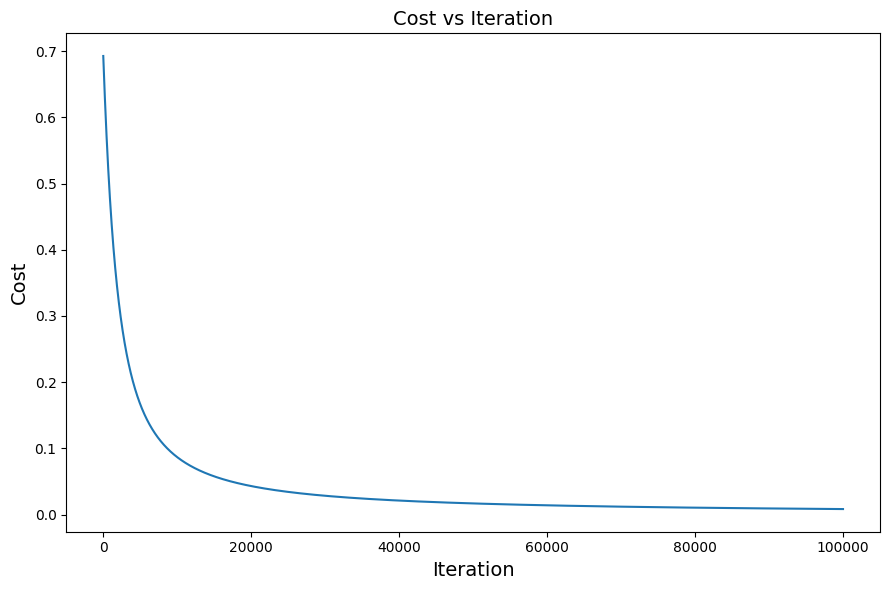

In [39]:
# Plotting cost over iteration:
import matplotlib.pyplot as plt
plt.figure(figsize = (9,6))
plt.plot(cost_history)
plt.xlabel("Iteration", fontsize = 14)
plt.ylabel("Cost", fontsize = 14)
plt.title("Cost vs Iteration", fontsize = 14)
plt.tight_layout()
plt.show()

In [41]:
#7 Decision/Prediction Function:
def prediction(X, w, b, threshold = 0.5):
    z = np.dot(X,w) + b
    y_test_prob = logistic_function(z)
    y_pred = (y_test_prob >= threshold).astype(int)
    return y_pred

In [48]:
# Test Case:
def test_prediction():
    X_test = np.array([[0.5,1.0],[1.5,-0.5],[-0.5,-1.0]])
    w_test = np.array([1.0,-1.0])
    b_test = 0.0
    threshold = 0.5
    expected_output = np.array([0,1,1])
    y_pred = prediction(X_test, w_test, b_test, threshold)
    assert np.array_equal(y_pred, expected_output), f"Expected : {expected_output}, but got {y_pred}"
    print("Test passed!")
test_prediction()

Test passed!


In [51]:
#8 Evaluation of classifier:
def evaluate_classification(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    confusion_matrix = np.array([[TN,FP],[FN,TP]])
    precision = TP / (TP + FP) if (TP + FP) > 0.0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    metrics = {
        "confusion_matrix" : confusion_matrix,
        "precision" : precision,
        "recall" : recall,
        "f1_score" : f1_score
    }
    return metrics

In [54]:
y_true = np.array([1,0,1,1,0,0,1])
y_pred = np.array([1,0,0,1,0,1,1])
metrics = evaluate_classification(y_true, y_pred)
print("Confusion Matrix : ", metrics["confusion_matrix"])
print("Precision : ", metrics["precision"])
print("Recall : ", metrics["recall"])
print("f1_score : ", metrics["f1_score"])

Confusion Matrix :  [[2 1]
 [1 3]]
Precision :  0.75
Recall :  0.75
f1_score :  0.75
